# Phase 1: Baseline Consolidation and Reproducibility
1. **Binary Classification**: AI vs Human Detection
2. **Multi-class Classification**: Writer Attribution (GPT-3.5, GPT-4, Claude, Gemini, Human)

## Data Loading and Preparation

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import xgboost as xgb
import torch
import joblib

df = pd.read_csv("data/DB_final.csv")
print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nClass distribution:")
print(df['Writer'].value_counts())
print(f"\nAI vs Human distribution:")
print(df['is_AI'].value_counts())

Dataset shape: (51181, 19)

Columns: ['Text', 'Writer', 'is_AI', 'gain', 'beauty', 'government', 'urban', 'art', 'help', 'optimism', 'strength', 'love', 'traveling', 'burstiness', 'ppl', 'syntax_depth', 'ttr', 'semantic_mean', 'semantic_std']

Class distribution:
Writer
GPT_4-o                              7321
accounts/yi-01-ai/models/yi-large    7319
mistral-7B                           7316
qwen-2-72B                           7314
gemma-2-9b                           7310
llama-8B                             7306
Human_story                          7295
Name: count, dtype: int64

AI vs Human distribution:
is_AI
1    43886
0     7295
Name: count, dtype: int64


In [3]:
# Check for missing values
if df.isnull().sum().sum() > 0:
    raise ValueError(f"Missing values found:\n{df.isnull().sum()[df.isnull().sum() > 0]}")
else:
    print("No missing values detected")

No missing values detected


# Binary Classification - AI vs Human Detection

In [4]:
X_binary = df.drop(columns=['Text', 'Writer', 'is_AI'])
y_binary = df['is_AI']

X_train_binary, X_test_binary, y_train_binary, y_test_binary = train_test_split(
    X_binary, 
    y_binary, 
    test_size=0.20, 
    random_state=999, 
    stratify=y_binary
)
print(f"X Train/Test: {X_train_binary.shape} , {X_test_binary.shape}")
print(f"z Train/Test: {len(y_train_binary)} , {len(y_test_binary)}")

X Train/Test: (40944, 16) , (10237, 16)
z Train/Test: 40944 , 10237


In [5]:
xgb_is_ai = xgb.XGBClassifier(
    objective='binary:logistic', 
    tree_method='hist',
    eval_metric=['logloss', 'auc'],
    device='cuda' if torch.cuda.is_available() else 'cpu',
    n_estimators=2000,
    early_stopping_rounds=50,
    learning_rate=0.05,
    max_depth=10,
    random_state=999,
)

print(f"Training binary classifier on {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}...")
xgb_is_ai.fit(
    X_train_binary, 
    y_train_binary, 
    eval_set=[(X_test_binary, y_test_binary)], 
    verbose=100
)
print("Binary classification training completed!")

Training binary classifier on NVIDIA GeForce RTX 3060...
[0]	validation_0-logloss:0.37148	validation_0-auc:0.97776
[100]	validation_0-logloss:0.05357	validation_0-auc:0.99540
[200]	validation_0-logloss:0.04995	validation_0-auc:0.99619
[300]	validation_0-logloss:0.05052	validation_0-auc:0.99629
[306]	validation_0-logloss:0.05068	validation_0-auc:0.99630
Binary classification training completed!


### 1.3 Evaluation - Binary Classification

BINARY CLASSIFICATION RESULTS - AI vs HUMAN DETECTION

Accuracy: 0.9836

Detailed Classification Report:
              precision    recall  f1-score   support

       Human       0.96      0.93      0.94      1459
          AI       0.99      0.99      0.99      8778

    accuracy                           0.98     10237
   macro avg       0.97      0.96      0.97     10237
weighted avg       0.98      0.98      0.98     10237



/home/basel/Work/python/ai_text_detection/.venv/lib/python3.11/site-packages/xgboost/core.py:774: UserWarning: [08:31:08] WARNING: /workspace/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


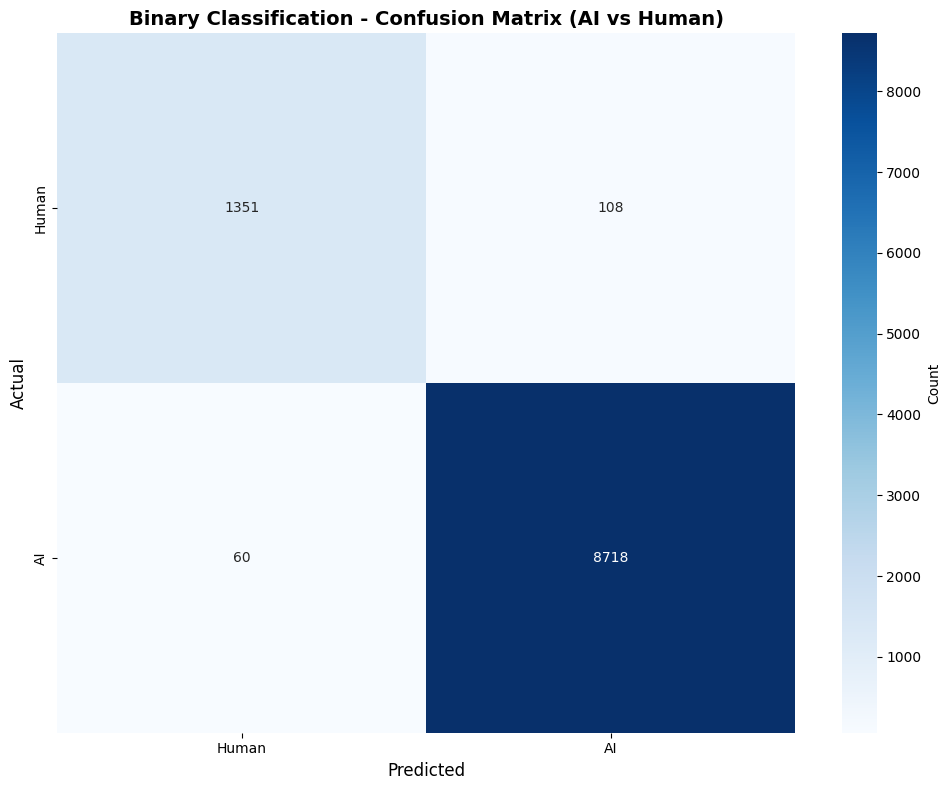


Top 20 Most Important Features for AI Detection:
          Feature  Importance
10     burstiness    0.366744
11            ppl    0.146635
1          beauty    0.091266
0            gain    0.071022
14  semantic_mean    0.049538
7        strength    0.040370
3           urban    0.031870
6        optimism    0.031642
15   semantic_std    0.028292
9       traveling    0.024355
8            love    0.024064
12   syntax_depth    0.023170
13            ttr    0.020769
5            help    0.020385
4             art    0.020191
2      government    0.009686


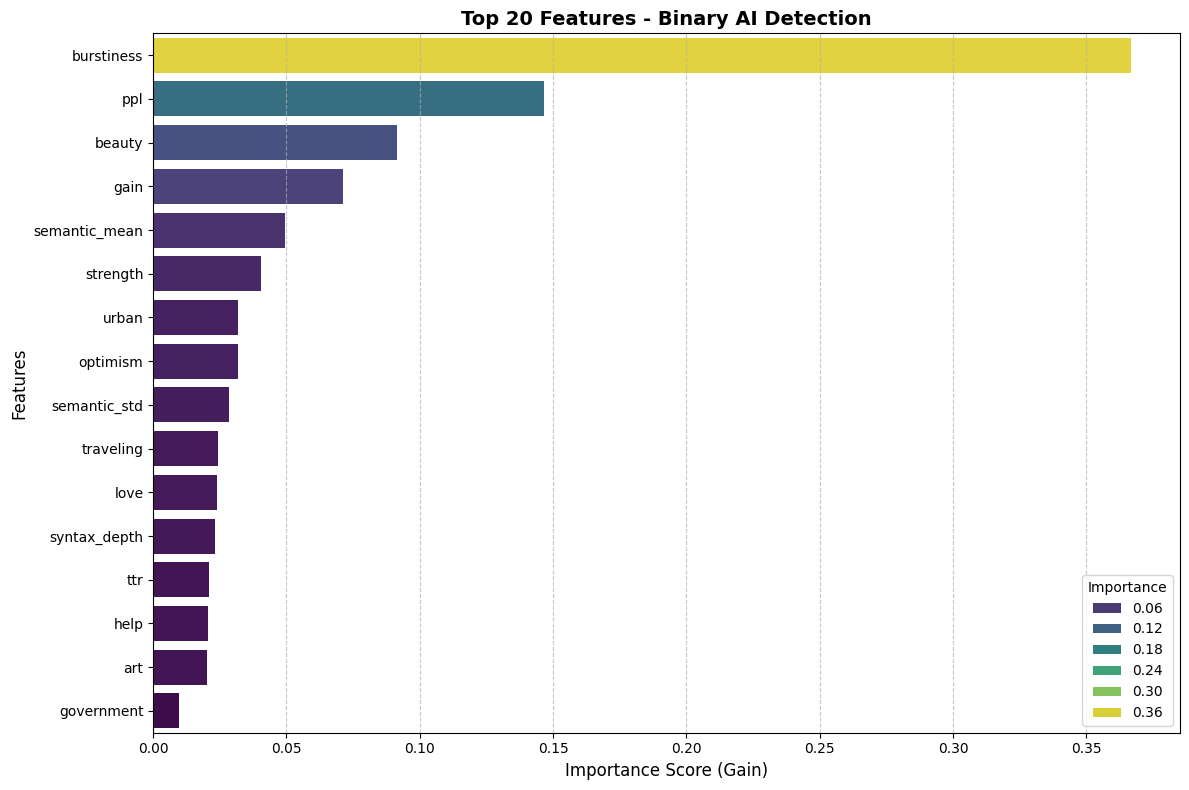

In [6]:
y_pred_binary = xgb_is_ai.predict(X_test_binary)
binary_accuracy = accuracy_score(y_test_binary, y_pred_binary)

print("BINARY CLASSIFICATION RESULTS - AI vs HUMAN DETECTION")
print(f"\nAccuracy: {binary_accuracy:.4f}")
print("\nDetailed Classification Report:")
print(classification_report(y_test_binary, y_pred_binary, target_names=['Human', 'AI']))
# Confusion Matrix
plt.figure(figsize=(10, 8))
cm_binary = confusion_matrix(y_test_binary, y_pred_binary)
sns.heatmap(cm_binary, annot=True, fmt='d', 
            xticklabels=['Human', 'AI'], 
            yticklabels=['Human', 'AI'], 
            cmap='Blues', cbar_kws={'label': 'Count'})
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title('Binary Classification - Confusion Matrix (AI vs Human)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Feature Importance - Binary Task
importances_binary = xgb_is_ai.feature_importances_
feature_importance_binary = pd.DataFrame({
    'Feature': X_binary.columns,
    'Importance': importances_binary
}).sort_values(by='Importance', ascending=False)

print("\nTop 20 Most Important Features for AI Detection:")
print(feature_importance_binary.head(20))

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', 
            data=feature_importance_binary.head(20), 
            palette='viridis',hue='Importance', dodge=False)
plt.title('Top 20 Features - Binary AI Detection', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score (Gain)', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [7]:
# Save binary model
joblib.dump(xgb_is_ai, 'models/xgb_is_ai_model.pkl')
print("Binary model saved to 'models/xgb_is_ai_model.pkl'")

Binary model saved to 'models/xgb_is_ai_model.pkl'


---
## Task 2: Multi-class Classification - Writer Attribution
Objective: Identify the specific writer/generator (GPT-3.5, GPT-4, Claude, Gemini, Human)

### 2.1 Data Preparation for Multi-class Task

In [8]:
X_multiclass = df.drop(columns=['Text', 'Writer', 'is_AI'])
y_multiclass = df['Writer']

le = LabelEncoder()
y_multiclass_encoded = le.fit_transform(y_multiclass)

X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(
    X_multiclass, 
    y_multiclass_encoded, 
    test_size=0.20, 
    random_state=999, 
    stratify=y_multiclass_encoded
)
print(f"X Train/Test: {X_train_multi.shape} , {X_test_multi.shape}")
print(f"y Train/Test: {len(y_train_multi)} , {len(y_test_multi)}")

X Train/Test: (40944, 16) , (10237, 16)
y Train/Test: 40944 , 10237


### 2.2 Model Training - Multi-class Classification

In [9]:
# Initialize multi-class XGBoost classifier
xgb_classifier = xgb.XGBClassifier(
    objective='multi:softprob',
    tree_method='hist',
    device='cuda' if torch.cuda.is_available() else 'cpu',
    eval_metric=['mlogloss', 'merror'],
    n_estimators=2000,
    early_stopping_rounds=100,
    learning_rate=0.05,
    max_depth=10,
    random_state=999
)

print(f"Training multi-class classifier on {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}...")
xgb_classifier.fit(
    X_train_multi, 
    y_train_multi, 
    eval_set=[(X_test_multi, y_test_multi)], 
    verbose=100
)
print("Multi-class classification training completed!")

Training multi-class classifier on NVIDIA GeForce RTX 3060...
[0]	validation_0-mlogloss:1.87340	validation_0-merror:0.38478
[100]	validation_0-mlogloss:0.80738	validation_0-merror:0.29833
[200]	validation_0-mlogloss:0.76251	validation_0-merror:0.28690
[300]	validation_0-mlogloss:0.76230	validation_0-merror:0.28241
[400]	validation_0-mlogloss:0.77123	validation_0-merror:0.28084
[491]	validation_0-mlogloss:0.78148	validation_0-merror:0.28231
Multi-class classification training completed!


### 2.3 Evaluation - Multi-class Classification

MULTI-CLASS CLASSIFICATION RESULTS - WRITER ATTRIBUTION

Accuracy: 0.7202

Detailed Classification Report:
                                   precision    recall  f1-score   support

                          GPT_4-o       0.86      0.86      0.86      1465
                      Human_story       0.93      0.94      0.94      1459
accounts/yi-01-ai/models/yi-large       0.70      0.73      0.72      1464
                       gemma-2-9b       0.76      0.82      0.79      1462
                         llama-8B       0.60      0.61      0.60      1461
                       mistral-7B       0.51      0.48      0.49      1463
                       qwen-2-72B       0.66      0.61      0.63      1463

                         accuracy                           0.72     10237
                        macro avg       0.72      0.72      0.72     10237
                     weighted avg       0.72      0.72      0.72     10237



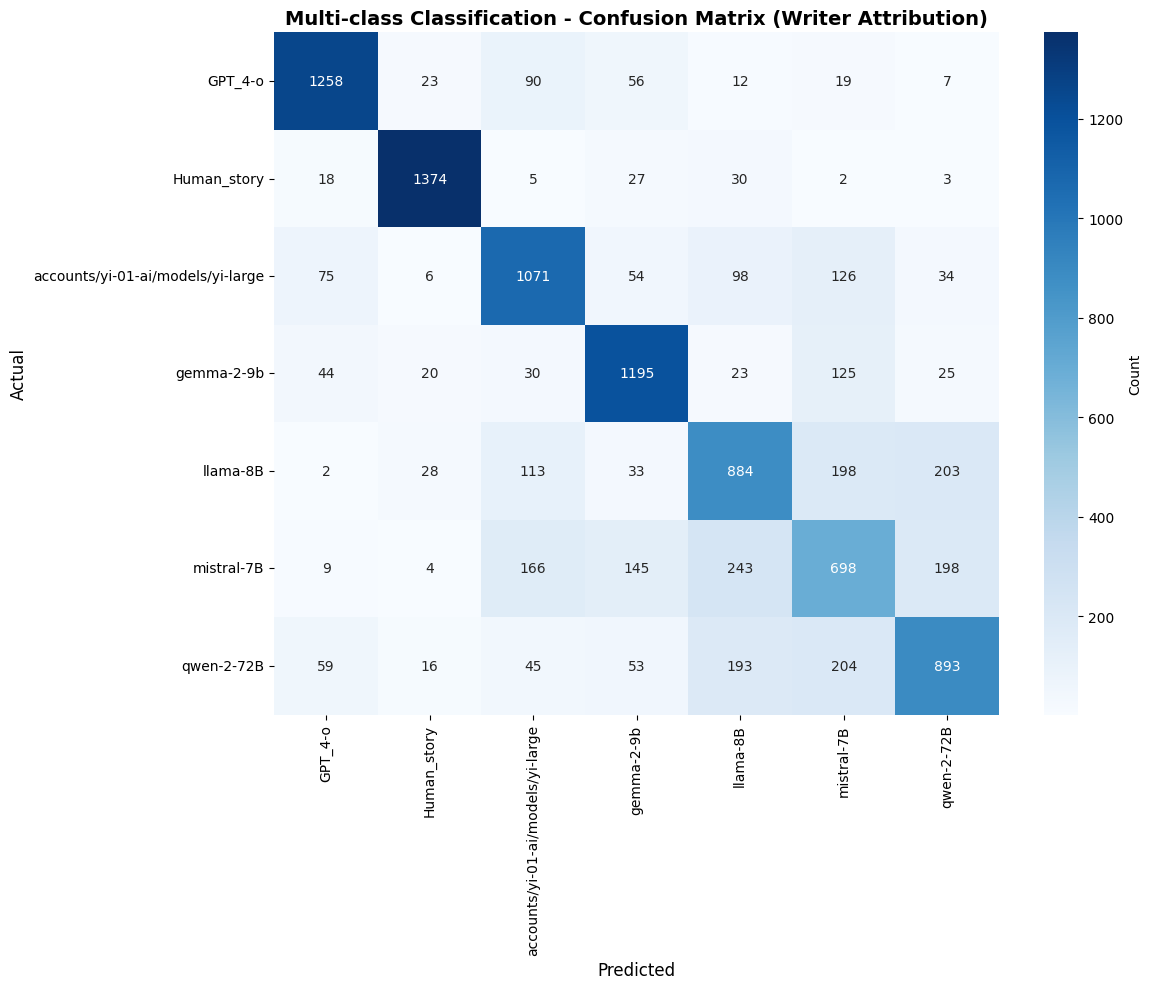


Top 20 Most Important Features for Writer Attribution:
          Feature  Importance
11            ppl    0.196564
10     burstiness    0.128036
13            ttr    0.085467
0            gain    0.061259
12   syntax_depth    0.057697
1          beauty    0.054924
3           urban    0.050850
7        strength    0.049065
14  semantic_mean    0.043782
5            help    0.043670
8            love    0.041674
2      government    0.040752
9       traveling    0.039667
4             art    0.038319
6        optimism    0.036777
15   semantic_std    0.031499


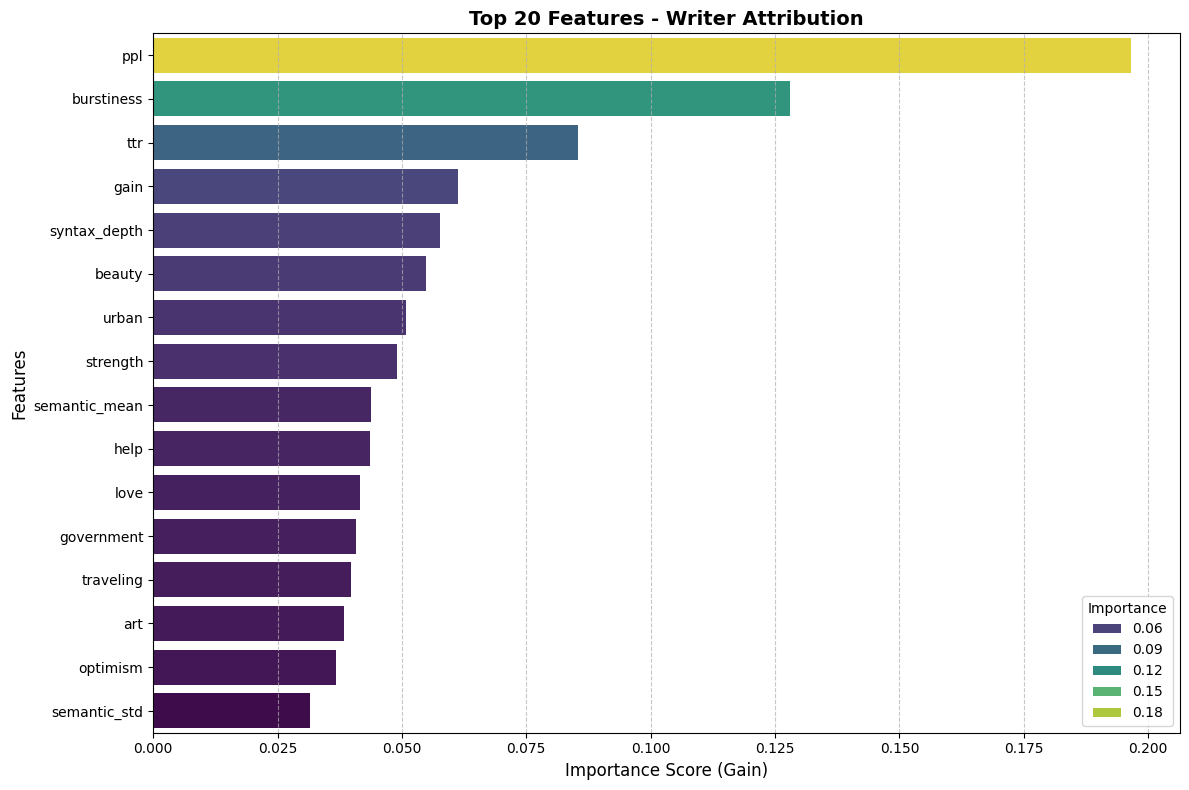

In [10]:
y_pred_multi = xgb_classifier.predict(X_test_multi)
multi_accuracy = accuracy_score(y_test_multi, y_pred_multi)

print("MULTI-CLASS CLASSIFICATION RESULTS - WRITER ATTRIBUTION")
print(f"\nAccuracy: {multi_accuracy:.4f}")
print("\nDetailed Classification Report:")
print(classification_report(y_test_multi, y_pred_multi, target_names=le.classes_))

# Confusion Matrix
plt.figure(figsize=(12, 10))
cm_multi = confusion_matrix(y_test_multi, y_pred_multi)
sns.heatmap(cm_multi, annot=True, fmt='d', 
            xticklabels=le.classes_, 
            yticklabels=le.classes_, 
            cmap='Blues', cbar_kws={'label': 'Count'})
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title('Multi-class Classification - Confusion Matrix (Writer Attribution)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Feature Importance - Multi-class Task
importances_multi = xgb_classifier.feature_importances_
feature_importance_multi = pd.DataFrame({
    'Feature': X_multiclass.columns,
    'Importance': importances_multi
}).sort_values(by='Importance', ascending=False)

print("\nTop 20 Most Important Features for Writer Attribution:")
print(feature_importance_multi.head(20))

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', 
            data=feature_importance_multi.head(20), 
            palette='viridis',
            hue='Importance', dodge=False)
plt.title('Top 20 Features - Writer Attribution', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score (Gain)', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [11]:
# Save multi-class model
joblib.dump(xgb_classifier, 'models/xgb_classifier_model.pkl')
print("Multi-class model saved to 'models/xgb_classifier_model.pkl'")

Multi-class model saved to 'models/xgb_classifier_model.pkl'


---
## Summary: Consolidated Performance Metrics

In [ ]:
# Create consolidated metrics table
from sklearn.metrics import precision_recall_fscore_support

# Binary metrics
binary_prec, binary_rec, binary_f1, _ = precision_recall_fscore_support(
    y_test_binary, y_pred_binary, average=None
)

# Multi-class metrics
multi_prec, multi_rec, multi_f1, _ = precision_recall_fscore_support(
    y_test_multi, y_pred_multi, average=None
)

print("\n" + "="*80)
print("CONSOLIDATED BASELINE PERFORMANCE REPORT")
print("="*80)

print("\n" + "="*80)
print("TASK 1: BINARY CLASSIFICATION (AI vs HUMAN)")
print("="*80)
binary_results = pd.DataFrame({
    'Class': ['Human', 'AI'],
    'Precision': binary_prec,
    'Recall': binary_rec,
    'F1-Score': binary_f1,
    'Support': [sum(y_test_binary == 0), sum(y_test_binary == 1)]
}).round(4)
print(binary_results.to_string(index=False))
print(f"\nOverall Accuracy: {binary_accuracy:.4f}")

print("\n" + "="*80)
print("TASK 2: MULTI-CLASS CLASSIFICATION (WRITER ATTRIBUTION)")
print("="*80)
multi_results = pd.DataFrame({
    'Class': le.classes_,
    'Precision': multi_prec,
    'Recall': multi_rec,
    'F1-Score': multi_f1,
    'Support': [sum(y_test_multi == i) for i in range(len(le.classes_))]
}).round(4)
print(multi_results.to_string(index=False))
print(f"\nOverall Accuracy: {multi_accuracy:.4f}")

print("\n" + "="*80)
print("EXPERIMENTAL CONFIGURATION")
print("="*80)
print(f"Dataset: data/DB_final.csv")
print(f"Total Samples: {len(df)}")
print(f"Feature Count: {X_binary.shape[1]}")
print(f"Train/Test Split: 80/20")
print(f"Random Seed: 999")
print(f"Model: XGBoost")
print(f"Hyperparameters:")
print(f"  - n_estimators: 2000")
print(f"  - learning_rate: 0.05")
print(f"  - max_depth: 10")
print(f"  - early_stopping_rounds: 50 (binary), 100 (multi-class)")
print("="*80)


CONSOLIDATED BASELINE PERFORMANCE REPORT

TASK 1: BINARY CLASSIFICATION (AI vs HUMAN)
Class  Precision  Recall  F1-Score  Support
Human     0.9575  0.9260    0.9415     1459
   AI     0.9878  0.9932    0.9905     8778

Overall Accuracy: 0.9836

TASK 2: MULTI-CLASS CLASSIFICATION (WRITER ATTRIBUTION)
                            Class  Precision  Recall  F1-Score  Support
                          GPT_4-o     0.8587  0.8587    0.8587     1465
                      Human_story     0.9341  0.9417    0.9379     1459
accounts/yi-01-ai/models/yi-large     0.7046  0.7316    0.7178     1464
                       gemma-2-9b     0.7646  0.8174    0.7901     1462
                         llama-8B     0.5961  0.6051    0.6005     1461
                       mistral-7B     0.5087  0.4771    0.4924     1463
                       qwen-2-72B     0.6552  0.6104    0.6320     1463

Overall Accuracy: 0.7202

EXPERIMENTAL CONFIGURATION
Dataset: data/DB_final.csv
Total Samples: 51181
Feature Count: 16
Tr